# Gym Members Exercise Tracking Analysis

## Project Overview

This project analyzes gym members' exercise habits, workout patterns, 
and fitness-related metrics using Python.

The objective is to explore the dataset, identify meaningful patterns, 
visualize relationships, and generate useful insights from the data.

## 1. Importing Required Libraries

In this section, we import the libraries required for data analysis 
and visualization.

- Pandas: Used for data manipulation and analysis.
- NumPy: Used for numerical computations.
- Matplotlib: Used for creating visualizations.
- Seaborn: Used for creating attractive statistical plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 2. Loading the Dataset

The dataset contains information about gym members, including their 
age, weight, workout type, workout duration, calories burned, 
experience level, and other fitness-related attributes.

We will load the CSV file using Pandas.

In [2]:
# Load dataset
df = pd.read_csv('gym_members_exercise_tracking.csv')

## 3. Data Inspection

Before performing analysis, we inspect the dataset to understand 
its structure and quality.

The following checks will be performed:

- Display the first and last few rows.
- Check the number of rows and columns.
- Examine column names and data types.
- Generate descriptive statistics.
- Identify missing values.
- Check for duplicate records.

In [3]:
# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Display last 5 rows
print("\nLast 5 rows of the dataset:")
print(df.tail())

# Dataset shape
print("\nDataset shape:")
print(df.shape)

# Column names
print("\nColumn names:")
print(df.columns)

# Dataset information
print("\nDataset information:")
df.info()

# Statistical summary
print("\nStatistical summary:")
print(df.describe())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

First 5 rows of the dataset:
   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.66      167      122           54   
3   25    Male         53.2        1.70      190      164           56   
4   38    Male         46.1        1.79      188      158           68   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.69           1313.0         Yoga            12.6   
1                      1.30            883.0         HIIT            33.9   
2                      1.11            677.0       Cardio            33.4   
3                      0.59            532.0     Strength            28.8   
4                      0.64            556.0     Strength            29.2   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experi

In [4]:
df.to_csv('gym_progress.csv', index=False)


## 4. Data Cleaning

Data cleaning is an important step in the data analysis process.

In this section, we will:

- Check and handle missing values.
- Remove duplicate records.
- Verify data types.
- Identify invalid values.
- Reset the DataFrame index.
- Save the cleaned dataset for further analysis.

The objective is to improve data quality before performing analysis.

In [25]:
# Load dataset
df = pd.read_csv("gym_progress.csv")

print("Original dataset:")
print(df.head())

# Remove duplicate rows
df = df.drop_duplicates()

# Handle missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Fill missing numerical values with median
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing categorical values with mode
categorical_columns = df.select_dtypes(exclude="number").columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

# Convert Date column into datetime format
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Remove invalid values
if "Weight (kg)" in df.columns:
    df = df[df["Weight (kg)"] > 0]

if "Session_Duration (hours)" in df.columns:
    df = df[df["Session_Duration (hours)"] > 0]
# Reset index
df = df.reset_index(drop=True)

# Display cleaned dataset
print("\nCleaned dataset:")
print(df.head())

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Save cleaned dataset
df.to_csv("cleaned_gym_progress.csv", index=False)

print("\nData cleaning completed successfully!")
print("Cleaned dataset saved as cleaned_gym_progress.csv")

Original dataset:
   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.66      167      122           54   
3   25    Male         53.2        1.70      190      164           56   
4   38    Male         46.1        1.79      188      158           68   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.69           1313.0         Yoga            12.6   
1                      1.30            883.0         HIIT            33.9   
2                      1.11            677.0       Cardio            33.4   
3                      0.59            532.0     Strength            28.8   
4                      0.64            556.0     Strength            29.2   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level 

## 5. Numerical Analysis Using NumPy

NumPy is used to perform numerical calculations efficiently.

In this section, we will calculate:

- Mean
- Median
- Minimum and maximum values
- Standard deviation
- Percentiles
- Total and average values
- Correlation between numerical variables

These calculations will help us understand the distribution 
and characteristics of the fitness-related data.

In [26]:
# Load cleaned dataset
df.to_csv("cleaned_gym_progress.csv", index=False)

print("Dataset loaded successfully!")

# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

print("\nNumerical columns:")
print(numeric_df.columns.tolist())

# Convert numerical data into NumPy array
data = numeric_df.to_numpy()

print("\nNumPy array:")
print("First 5 rows of NumPy array:")
print(data[:5])

print("Array shape:")
print(data.shape)

# Shape of the NumPy array
print("\nArray shape:")
print(data.shape)

# Basic statistical analysis
print("\nMean of each numerical column:")
print(np.mean(data, axis=0))

print("\nMedian of each numerical column:")
print(np.median(data, axis=0))

print("\nMinimum value of each column:")
print(np.min(data, axis=0))

print("\nMaximum value of each column:")
print(np.max(data, axis=0))

print("\nStandard deviation of each column:")
print(np.std(data, axis=0))

# Percentile analysis
print("\n25th percentile:")
print(np.percentile(data, 25, axis=0))

print("\n75th percentile:")
print(np.percentile(data, 75, axis=0))

# Correlation matrix
print("\nCorrelation matrix:")
print(np.corrcoef(data, rowvar=False))

# Total and average values
print("\nTotal of each numerical column:")
print(np.sum(data, axis=0))

print("\nAverage of each numerical column:")
print(np.average(data, axis=0))

Dataset loaded successfully!

Numerical columns:
['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

NumPy array:
First 5 rows of NumPy array:
[[5.600e+01 8.830e+01 1.710e+00 1.800e+02 1.570e+02 6.000e+01 1.690e+00
  1.313e+03 1.260e+01 3.500e+00 4.000e+00 3.000e+00 3.020e+01]
 [4.600e+01 7.490e+01 1.530e+00 1.790e+02 1.510e+02 6.600e+01 1.300e+00
  8.830e+02 3.390e+01 2.100e+00 4.000e+00 2.000e+00 3.200e+01]
 [3.200e+01 6.810e+01 1.660e+00 1.670e+02 1.220e+02 5.400e+01 1.110e+00
  6.770e+02 3.340e+01 2.300e+00 4.000e+00 2.000e+00 2.471e+01]
 [2.500e+01 5.320e+01 1.700e+00 1.900e+02 1.640e+02 5.600e+01 5.900e-01
  5.320e+02 2.880e+01 2.100e+00 3.000e+00 1.000e+00 1.841e+01]
 [3.800e+01 4.610e+01 1.790e+00 1.880e+02 1.580e+02 6.800e+01 6.400e-01
  5.560e+02 2.920e+01 2.800e+00 3.000e+00 1.000e+00 1.439e+01]]
Array sh

## 6. Exploratory Data Analysis and Visualization

Data visualization helps us identify patterns, trends, and 
relationships that may not be easily visible in raw data.

In this section, we will create different plots to analyze:

- Age distribution
- Workout type distribution
- Calories burned
- Workout duration and calories relationship
- Calories burned by workout type
- Correlation between numerical variables
- Gender distribution
- Workout frequency and calories burned

In [7]:
# Load dataset
df = pd.read_csv("gym_members_exercise_tracking.csv")

# Create output folder
os.makedirs("visualizations", exist_ok=True)

# Visualization theme
sns.set_theme(style="whitegrid", context="notebook")

### 6.1 Age Distribution of Gym Members

A histogram is used to understand how gym members are distributed 
across different age groups.

This visualization helps identify the most common age ranges 
represented in the dataset.

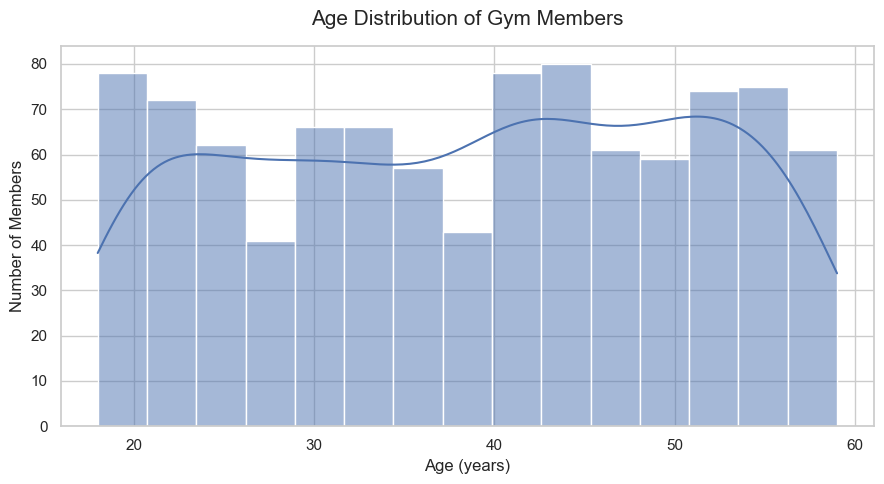

In [8]:

plt.figure(figsize=(9, 5))

sns.histplot(data=df, x="Age", bins=15, kde=True)

plt.title("Age Distribution of Gym Members", fontsize=15, pad=15)
plt.xlabel("Age (years)")
plt.ylabel("Number of Members")
plt.tight_layout()

plt.savefig("visualizations/age_distribution.png", dpi=300)
plt.show()
plt.close()

**Interpretation:**

The age distribution shows how gym members are spread across 
different age groups. The average age of the members is approximately 
38.68 years.

In [9]:
print(
    f"The average age of gym members is {df['Age'].mean():.2f} years. "
    "The histogram shows how members are distributed across different age groups."
)

The average age of gym members is 38.68 years. The histogram shows how members are distributed across different age groups.


### 6.2 Distribution of Workout Types

A bar chart is used to compare the number of members participating 
in different workout types, such as Strength, Cardio, Yoga, and HIIT.

This helps us understand the popularity of different workout types 
among the gym members.

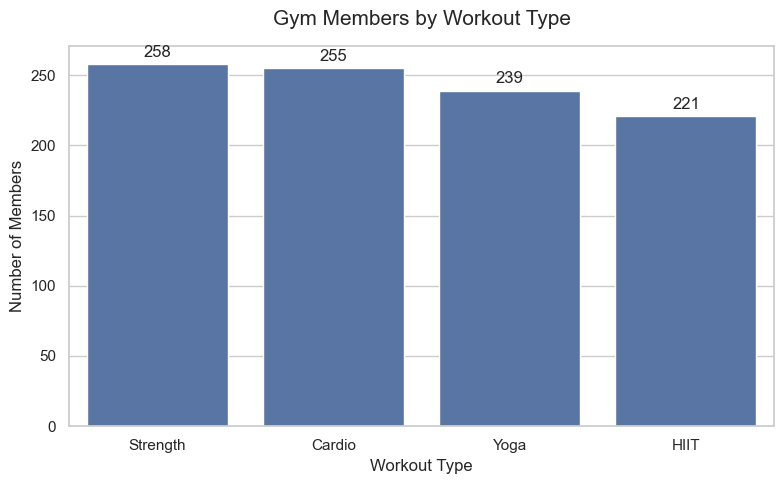

In [10]:
workout_counts = df["Workout_Type"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=workout_counts.index,
    y=workout_counts.values
)

plt.title("Gym Members by Workout Type", fontsize=15, pad=15)
plt.xlabel("Workout Type")
plt.ylabel("Number of Members")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.savefig("visualizations/workout_type_distribution.png", dpi=300)
plt.show()
plt.close()


**Interpretation:**

Strength training has the highest number of members, while HIIT has 
the lowest number of members in this dataset.

In [11]:
most_common_workout = workout_counts.idxmax()
least_common_workout = workout_counts.idxmin()
print(
    f"{most_common_workout} has the highest number of members "
    f"({workout_counts.max()}), while {least_common_workout} "
    f"has the lowest ({workout_counts.min()})."
)

Strength has the highest number of members (258), while HIIT has the lowest (221).


### 6.3 Distribution of Calories Burned

A histogram is used to analyze the distribution of calories burned 
during workout sessions.

This helps us understand the typical calorie expenditure and 
identify unusually high or low values.

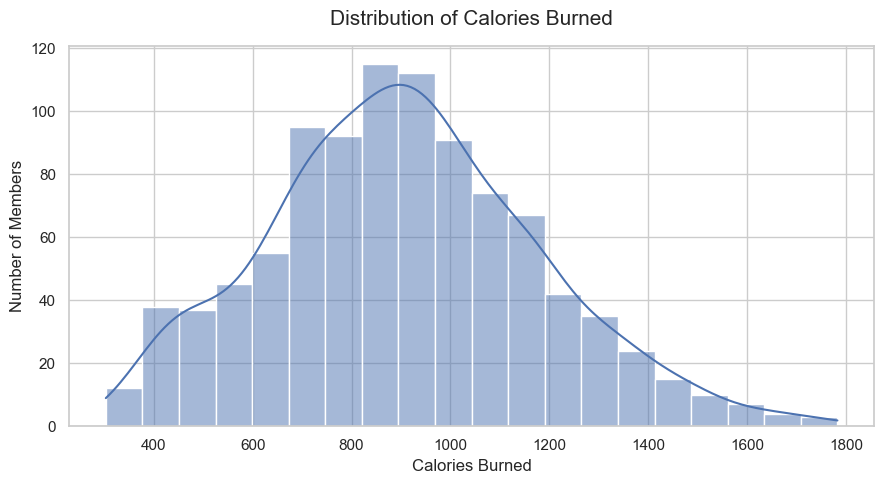

In [12]:
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x="Calories_Burned", bins=20, kde=True)

plt.title("Distribution of Calories Burned", fontsize=15, pad=15)
plt.xlabel("Calories Burned")
plt.ylabel("Number of Members")
plt.tight_layout()

plt.savefig("visualizations/calories_distribution.png", dpi=300)
plt.show()
plt.close()

**Interpretation:**

The average calorie expenditure per workout session is approximately 
905.42 calories. The histogram shows how calorie expenditure varies 
among gym members.

In [13]:
print(
    f"Members burn an average of {df['Calories_Burned'].mean():.2f} "
    "calories per session. The histogram shows the spread of calorie burn."
)

Members burn an average of 905.42 calories per session. The histogram shows the spread of calorie burn.


### 6.4 Relationship Between Session Duration and Calories Burned

A scatter plot is used to examine the relationship between workout 
session duration and calories burned.

Workout type is represented using different colors to compare 
patterns across workout categories.

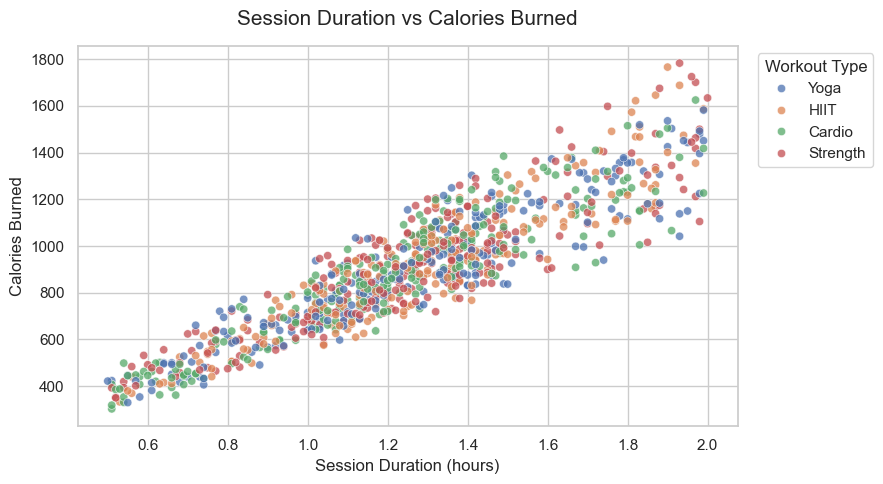

In [14]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Session_Duration (hours)",
    y="Calories_Burned",
    hue="Workout_Type",
    alpha=0.75
)

plt.title("Session Duration vs Calories Burned", fontsize=15, pad=15)
plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.legend(title="Workout Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("visualizations/duration_vs_calories.png", dpi=300)
plt.show()
plt.close()

**Interpretation:**

Session duration and calories burned have a strong positive correlation 
of approximately 0.91 in this dataset.

This indicates that longer workout sessions are generally associated 
with higher calorie expenditure.

However, correlation does not prove causation.

In [15]:
duration_correlation = df[
    ["Session_Duration (hours)", "Calories_Burned"]
].corr().iloc[0, 1]

print("\n--- Session Duration vs Calories Interpretation ---")
print(
    f"Session duration and calories burned have a correlation of "
    f"{duration_correlation:.2f}, indicating a strong positive "
    "relationship in this dataset."
)


--- Session Duration vs Calories Interpretation ---
Session duration and calories burned have a correlation of 0.91, indicating a strong positive relationship in this dataset.


### 6.5 Average Calories Burned by Workout Type

A bar chart is used to compare the average calories burned across 
different workout types.

This helps identify differences in average calorie expenditure 
between workout categories.

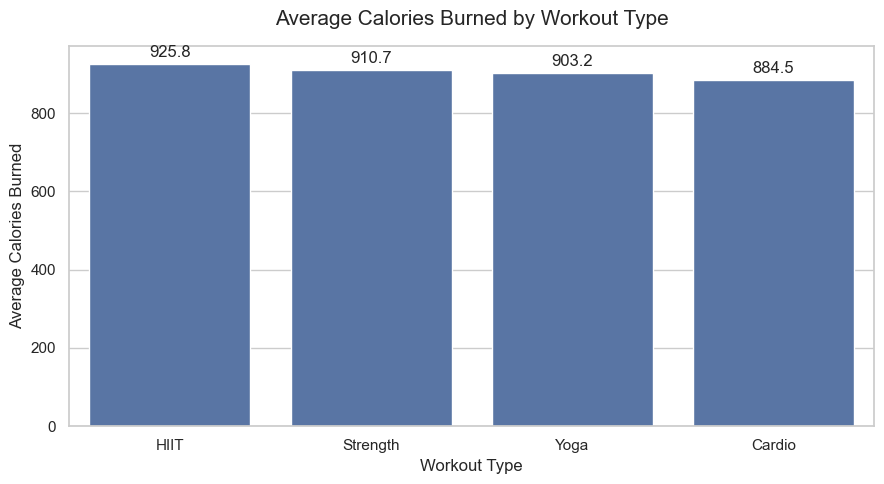

In [16]:
workout_calories = (
    df.groupby("Workout_Type")["Calories_Burned"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=workout_calories.index,
    y=workout_calories.values
)

plt.title("Average Calories Burned by Workout Type", fontsize=15, pad=15)
plt.xlabel("Workout Type")
plt.ylabel("Average Calories Burned")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.savefig("visualizations/calories_by_workout.png", dpi=300)
plt.show()
plt.close()

**Interpretation:**

HIIT has the highest average calorie expenditure at approximately 
925.81 calories, while Cardio has the lowest average at approximately 
884.51 calories.

These results describe this dataset only and do not establish that 
one workout type is universally better than another.

In [17]:
print(
    f"{workout_calories.idxmax()} has the highest average calorie burn "
    f"({workout_calories.max():.2f}), while "
    f"{workout_calories.idxmin()} has the lowest "
    f"({workout_calories.min():.2f})."
)

HIIT has the highest average calorie burn (925.81), while Cardio has the lowest (884.51).


### 6.6 Correlation Heatmap of Fitness Metrics

A correlation heatmap is used to visualize the relationships between 
numerical variables in the dataset.

Correlation values range from -1 to +1:

- A value close to +1 indicates a strong positive relationship.
- A value close to -1 indicates a strong negative relationship.
- A value close to 0 indicates a weak or no linear relationship.

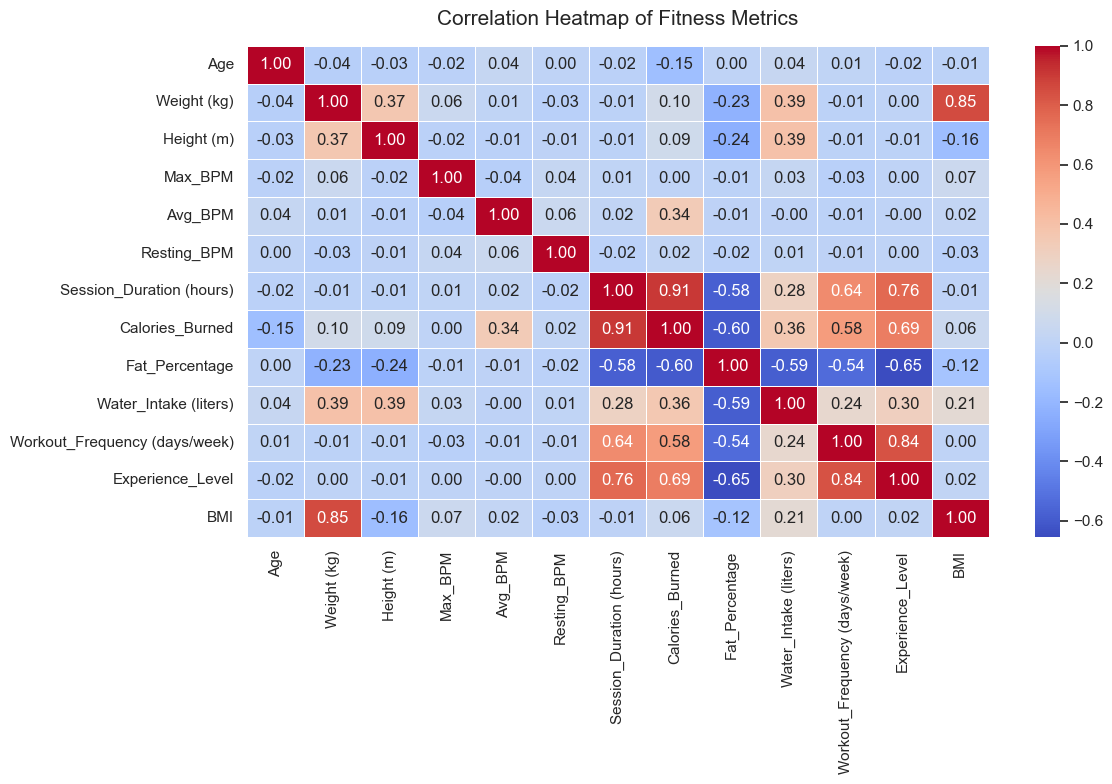

In [18]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Fitness Metrics", fontsize=15, pad=15)
plt.tight_layout()

plt.savefig("visualizations/correlation_heatmap.png", dpi=300)
plt.show()
plt.close()

calories_correlation = (
    correlation_matrix["Calories_Burned"]
    .drop("Calories_Burned")
    .sort_values(ascending=False)
)

**Interpretation:**

Session duration has the strongest positive correlation with calories 
burned, with a correlation coefficient of approximately 0.91.

Fat percentage has a negative correlation of approximately -0.60 
with calories burned.

Correlation does not imply a cause-and-effect relationship.

In [19]:
print(
    f"The variable most positively correlated with calories burned is "
    f"{calories_correlation.idxmax()} "
    f"({calories_correlation.max():.2f})."
)

print(
    f"The strongest negative correlation with calories burned is "
    f"{calories_correlation.idxmin()} "
    f"({calories_correlation.min():.2f})."
)


The variable most positively correlated with calories burned is Session_Duration (hours) (0.91).
The strongest negative correlation with calories burned is Fat_Percentage (-0.60).


### 6.7 Gender Distribution of Gym Members

A pie chart is used to show the proportion of male and female members 
in the dataset.

This visualization helps us understand the gender composition 
of the available data.

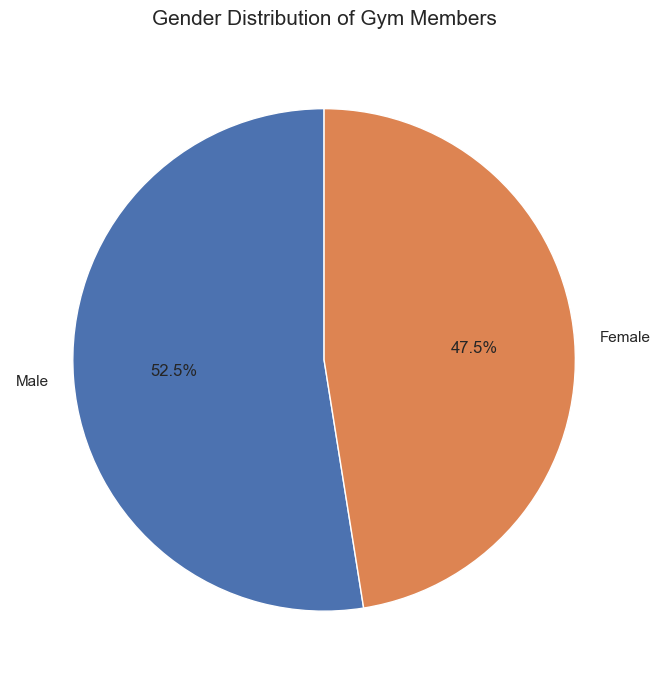

In [20]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Gender Distribution of Gym Members", fontsize=15, pad=15)
plt.tight_layout()

plt.savefig("visualizations/gender_distribution.png", dpi=300)
plt.show()
plt.close()

**Interpretation:**

The dataset contains 511 male members and 462 female members.

The number of male and female members is relatively close, although 
male members represent a slightly larger proportion of the dataset.

In [21]:
print(
    f"The dataset contains {gender_counts.get('Male', 0)} male members "
    f"and {gender_counts.get('Female', 0)} female members."
)

The dataset contains 511 male members and 462 female members.


### 6.8 Workout Frequency and Calories Burned

A box plot is used to compare the distribution of calories burned 
at different weekly workout frequencies.

The box plot helps identify the median, spread, and possible outliers 
for each workout frequency group.

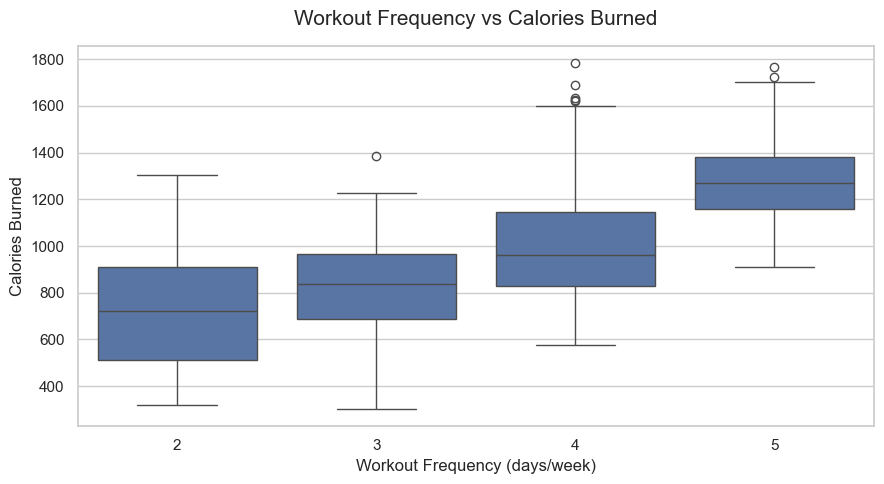

In [22]:
frequency_order = sorted(df["Workout_Frequency (days/week)"].unique())

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Workout_Frequency (days/week)",
    y="Calories_Burned",
    order=frequency_order
)

plt.title("Workout Frequency vs Calories Burned", fontsize=15, pad=15)
plt.xlabel("Workout Frequency (days/week)")
plt.ylabel("Calories Burned")
plt.tight_layout()

plt.savefig("visualizations/frequency_vs_calories.png", dpi=300)
plt.show()
plt.close()


**Interpretation:**

The box plot compares calorie expenditure across different workout 
frequencies.

It helps identify how the median and variation in calories burned 
change across weekly workout frequency groups.

The highest average calorie burn is observed at workout frequency 5 days/week (1277.57 calories).


In [27]:

frequency_calories = df.groupby(
    "Workout_Frequency (days/week)"
)["Calories_Burned"].mean()

print(
    f"The highest average calorie burn is observed at workout frequency "
    f"{frequency_calories.idxmax()} days/week "
    f"({frequency_calories.max():.2f} calories)."
)




The highest average calorie burn is observed at workout frequency 5 days/week (1277.57 calories).

All graphs and interpretations generated successfully!
Graphs saved in the 'visualizations' folder.


In [28]:
print("All graphs and interpretations generated successfully!")
print("Graphs saved in the 'visualizations' folder.")


All graphs and interpretations generated successfully!
Graphs saved in the 'visualizations' folder.


## 7. Key Findings

The major findings from the analysis are:

1. The dataset contains 973 gym members and 15 columns.
2. The average age of gym members is approximately 38.68 years.
3. The average workout session duration is approximately 1.26 hours.
4. HIIT has the highest average calorie expenditure among the workout types.
5. Session duration has a strong positive correlation of 0.91 with calories burned.
6. Fat percentage has a negative correlation of approximately -0.60 with calories burned.
7. Male members are slightly more represented than female members in the dataset.

These findings are based on the available dataset and should not be 
generalized to all gym members.

In [24]:
# Load dataset
df = pd.read_csv("gym_members_exercise_tracking.csv")

print("=" * 60)
print("GYM MEMBERS EXERCISE TRACKING - INSIGHTS REPORT")
print("=" * 60)

# Basic information
print("\n1. BASIC DATASET INSIGHTS")
print(f"Total gym members: {len(df)}")
print(f"Total columns: {len(df.columns)}")

# Average statistics
print("\n2. AVERAGE FITNESS METRICS")

numeric_columns = [
    "Age",
    "Weight (kg)",
    "Height (m)",
    "Calories_Burned",
    "Session_Duration (hours)",
    "Fat_Percentage",
    "Water_Intake (liters)",
    "Workout_Frequency (days/week)"
]

for column in numeric_columns:
    if column in df.columns:
        print(f"Average {column}: {df[column].mean():.2f}")


# Workout type analysis
if "Workout_Type" in df.columns:
    print("\n3. WORKOUT TYPE ANALYSIS")

    workout_count = df["Workout_Type"].value_counts()
    print("\nMembers by workout type:")
    print(workout_count)

    if "Calories_Burned" in df.columns:
        average_calories = df.groupby("Workout_Type")[
            "Calories_Burned"
        ].mean().sort_values(ascending=False)

        print("\nAverage calories burned by workout type:")
        print(average_calories)

        print(
            f"\nWorkout type with highest average calories burned: "
            f"{average_calories.idxmax()}"
        )


# Gender analysis
if "Gender" in df.columns:
    print("\n4. GENDER ANALYSIS")
    print(df["Gender"].value_counts())

    if "Calories_Burned" in df.columns:
        gender_calories = df.groupby("Gender")[
            "Calories_Burned"
        ].mean()

        print("\nAverage calories burned by gender:")
        print(gender_calories)


# Experience-level analysis
if "Experience_Level" in df.columns:
    print("\n5. EXPERIENCE LEVEL ANALYSIS")

    experience_count = df["Experience_Level"].value_counts()
    print("\nMembers by experience level:")
    print(experience_count)

    if "Calories_Burned" in df.columns:
        experience_calories = df.groupby("Experience_Level")[
            "Calories_Burned"
        ].mean()

        print("\nAverage calories burned by experience level:")
        print(experience_calories)


# Correlation analysis
print("\n6. CORRELATION INSIGHTS")

numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

if "Calories_Burned" in correlation_matrix.columns:
    calories_correlation = (
        correlation_matrix["Calories_Burned"]
        .drop("Calories_Burned")
        .sort_values(ascending=False)
    )

    print("\nCorrelation with calories burned:")
    print(calories_correlation)

    print(
        "\nVariable most positively correlated with calories burned: "
        f"{calories_correlation.idxmax()}"
    )


# Workout duration analysis
if (
    "Session_Duration (hours)" in df.columns
    and "Calories_Burned" in df.columns
):
    print("\n7. WORKOUT DURATION INSIGHT")

    duration_correlation = df[
        ["Session_Duration (hours)", "Calories_Burned"]
    ].corr().iloc[0, 1]

    print(
        "Correlation between workout duration and calories burned: "
        f"{duration_correlation:.2f}"
    )

    if duration_correlation > 0:
        print("Interpretation: Positive relationship observed in this dataset.")
    elif duration_correlation < 0:
        print("Interpretation: Negative relationship observed in this dataset.")
    else:
        print("Interpretation: No linear relationship observed.")


# Save report
with open("gym_insights_report.txt", "w", encoding="utf-8") as file:
    file.write("Gym Members Exercise Tracking - Insights Report\n")
    file.write("=" * 55 + "\n\n")

    file.write(f"Total members: {len(df)}\n\n")

    file.write("Average numerical values:\n")
    file.write(df.select_dtypes(include="number").mean().to_string())

    file.write("\n\nCorrelation matrix:\n")
    file.write(correlation_matrix.to_string())

print("\nInsights report saved as gym_insights_report.txt")


GYM MEMBERS EXERCISE TRACKING - INSIGHTS REPORT

1. BASIC DATASET INSIGHTS
Total gym members: 973
Total columns: 15

2. AVERAGE FITNESS METRICS
Average Age: 38.68
Average Weight (kg): 73.85
Average Height (m): 1.72
Average Calories_Burned: 905.42
Average Session_Duration (hours): 1.26
Average Fat_Percentage: 24.98
Average Water_Intake (liters): 2.63
Average Workout_Frequency (days/week): 3.32

3. WORKOUT TYPE ANALYSIS

Members by workout type:
Workout_Type
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64

Average calories burned by workout type:
Workout_Type
HIIT        925.805430
Strength    910.697674
Yoga        903.188285
Cardio      884.513725
Name: Calories_Burned, dtype: float64

Workout type with highest average calories burned: HIIT

4. GENDER ANALYSIS
Gender
Male      511
Female    462
Name: count, dtype: int64

Average calories burned by gender:
Gender
Female    862.248918
Male      944.455969
Name: Calories_Burned, dtype: float64

5.

## 8. Conclusion

This project explored gym member's exercise habits and fitness metrics 
using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis showed that workout duration had the strongest positive 
relationship with calories burned in this dataset. Differences were 
also observed in calorie expenditure across workout types and 
experience levels.

This project helped demonstrate the complete data analysis process, 
including data inspection, data cleaning, numerical analysis, 
visualization, and insight generation.

### Future Improvements

- Build an interactive dashboard using Power BI.
- Perform statistical hypothesis testing.
- Analyze outliers in greater detail.
- Develop a machine learning model to predict calories burned.

## 9. Final Summary

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- JupyterLab

### Project Outcome

The project successfully analyzed gym member's exercise data and 
identified important patterns related to workout duration, workout 
types, experience levels, and calorie expenditure.